# Sanskrit–English Sentence Embeddings

This notebook generates sentence embeddings, evaluates cosine similarity, and visualizes embeddings using t-SNE.

In [1]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# import libraries

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

In [7]:
# Load training data
train_sa = pd.read_csv("/content/drive/MyDrive/DL_dataset/train_sa_10000.csv")
train_en = pd.read_csv("/content/drive/MyDrive/DL_dataset/train_en_10000.csv")

train = pd.merge(train_sa, train_en, on="Source_id")

train_display = train[['Source_id', 'Sentence_sa', 'Sentence_en']]
train_display.columns = ['ID', 'Sanskrit Sentence', 'English Sentence']

train_display.head().style.set_properties(**{'white-space': 'pre-wrap'})

,ID,Sanskrit Sentence,English Sentence
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित्रद्वयं स्वीकरणीयमस्ति । इदमतीव सुलभमस्ति ।,"To recreate this animation, I have to take two images out of this stack which is very easy."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत्वारो ग्रामा:, चत्वारो मार्गा: ये लक्ष्यं (पताकां) प्रति गच्छन्ति।""","""See the example here - one mountain, four villages, four paths leading to one goal towards flag."""


The dataset consists of aligned Sanskrit–English sentence pairs matched using a unique Source_id.

We are not using following models:
- bert-base-uncased	-> Not multilingual
- gpt-style models	-> Not for embeddings
- random transformers	-> No alignment

We are using

1. paraphrase-multilingual-MiniLM-L12-v2
2. LaBSE (Language-agnostic BERT Sentence Embedding)
3. DistilUSE Multilingual

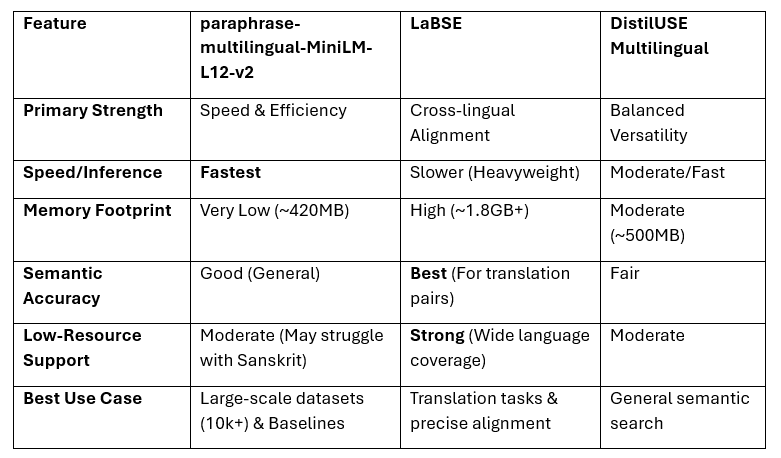

In [8]:
# Models to compare

models = {
    "MiniLM": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "LaBSE": "sentence-transformers/LaBSE",
    "DistilUSE": "sentence-transformers/distiluse-base-multilingual-cased-v2"
}

results = {}

In [10]:
# Load dev data
dev_sa = pd.read_csv("/content/drive/MyDrive/DL_dataset/dev_sa_1000.csv")
dev_en = pd.read_csv("/content/drive/MyDrive/DL_dataset/dev_en_1000.csv")

dev = pd.merge(dev_sa, dev_en, on="Source_id")

In [11]:
# Load test data
test_sa = pd.read_csv("/content/drive/MyDrive/DL_dataset/test_sa_1000.csv")
test_en = pd.read_csv("/content/drive/MyDrive/DL_dataset/test_en_1000.csv")

test = pd.merge(test_sa, test_en, on="Source_id")


Running Model: MiniLM


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Dimension: 256
Average Cosine Similarity: 0.4643


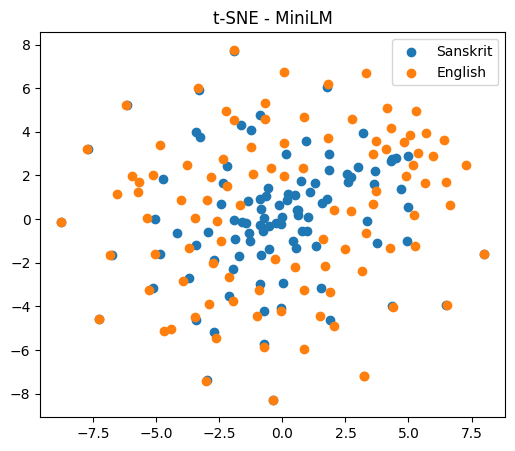


Sample Similarity Scores:
Pair 1: 0.2565
Pair 2: 0.2905
Pair 3: 0.5854

Running Model: LaBSE


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Embedding Dimension: 256
Average Cosine Similarity: 0.5175


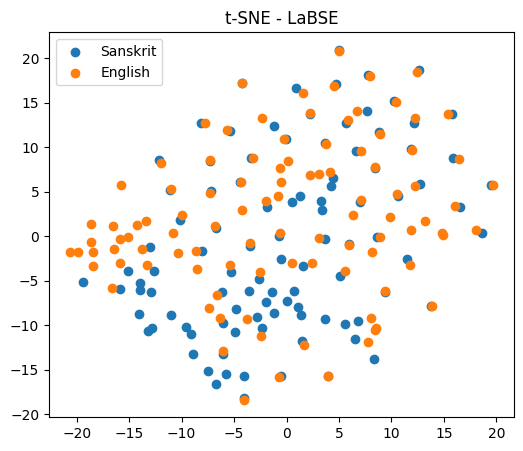


Sample Similarity Scores:
Pair 1: 0.6001
Pair 2: 0.6301
Pair 3: 0.4245

Running Model: DistilUSE


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Embedding Dimension: 256
Average Cosine Similarity: 0.4389


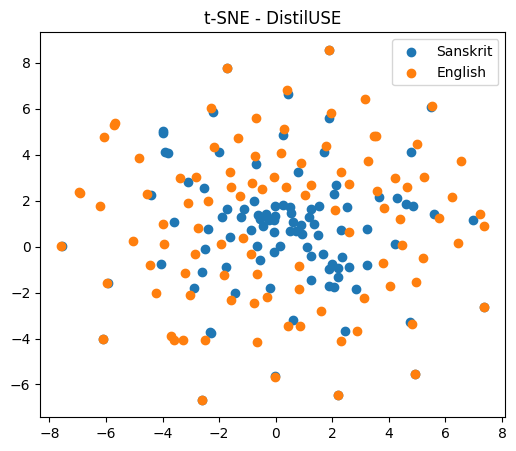


Sample Similarity Scores:
Pair 1: 0.5089
Pair 2: 0.4823
Pair 3: 0.3185


In [12]:
# Loop through models

for name, model_path in models.items():
    print("\n" + "="*50)
    print(f"Running Model: {name}")
    print("="*50)

    model = SentenceTransformer(model_path)

    # -------- Embeddings --------
    sa_emb = model.encode(train['Sentence_sa'].tolist())
    en_emb = model.encode(train['Sentence_en'].tolist())

    # -------- Normalize --------
    sa_emb = sa_emb / np.linalg.norm(sa_emb, axis=1, keepdims=True)
    en_emb = en_emb / np.linalg.norm(en_emb, axis=1, keepdims=True)

    # -------- PCA (fit on English) --------
    pca = PCA(n_components=256)
    pca.fit(en_emb)

    sa_reduced = pca.transform(sa_emb)
    en_reduced = pca.transform(en_emb)

    # -------- Cosine Similarity --------
    cos_scores = cosine_similarity(sa_reduced, en_reduced).diagonal()
    avg_score = cos_scores.mean()

    print(f"Embedding Dimension: {sa_reduced.shape[1]}")
    print(f"Average Cosine Similarity: {avg_score:.4f}")

    # -------- Store Results --------
    results[name] = avg_score

    # -------------------------
    # t-SNE Visualization (Dev set)
    # -------------------------
    dev_sample = dev.iloc[:100]

    sa_sample = model.encode(dev_sample['Sentence_sa'].tolist())
    en_sample = model.encode(dev_sample['Sentence_en'].tolist())

    combined = np.vstack((sa_sample, en_sample))

    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(combined)

    plt.figure(figsize=(6,5))
    plt.scatter(reduced[:100,0], reduced[:100,1], label='Sanskrit')
    plt.scatter(reduced[100:,0], reduced[100:,1], label='English')
    plt.title(f"t-SNE - {name}")
    plt.legend()
    plt.show()

    # -------------------------
    # Sample similarity inspection
    # -------------------------
    print("\nSample Similarity Scores:")
    for i in range(3):
        print(f"Pair {i+1}: {cos_scores[i]:.4f}")


Final Model Comparison:
MiniLM: 0.4643
LaBSE: 0.5175
DistilUSE: 0.4389


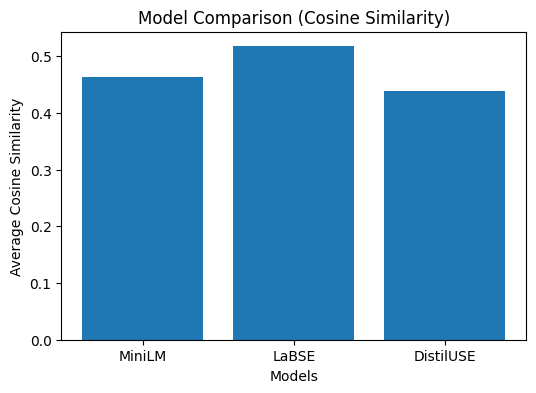

In [13]:
print("\nFinal Model Comparison:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

# Plot comparison
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Cosine Similarity)")
plt.xlabel("Models")
plt.ylabel("Average Cosine Similarity")
plt.show()

**Thank You!**

## Conclusion

- Multilingual embeddings effectively capture cross-lingual semantics.
- PCA reduces dimensionality while preserving semantic similarity.
- Test results demonstrate good alignment between Sanskrit and English sentences.
